# Notebook 18 — Primal attack on LWE

The payoff: take a toy LWE instance, build the Kannan-embedding lattice, BKZ-reduce it, and watch the secret fall out.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
from pqc_edu.lwe import toy_keygen
from pqc_edu.attacks_advanced.primal import primal_attack

## Kannan's embedding, informally

Given LWE samples $A \cdot s + e \equiv b \pmod q$, we build a lattice containing the vector $(e, -s, 1)$ (up to scaling). That vector is short because $e, s$ are small. If BKZ finds a short enough basis, we read $s$ right off.

The basis layout (rows, dimension $m + n + 1$):

- $n$ rows of $(A[:,j], e_j, 0)$
- $m$ rows of $(q \cdot e_i, 0, 0)$
- $1$ row of $(b, 0, M)$

Why it works: any lattice point has last coord = $M \cdot t$ for some integer $t$. Setting $t = 1$ and choosing coefficients to cancel $b$ against $As$, the residue in the first $m$ coords becomes $e$.

**Important**: this attack only works when $s$ is **small**. We use `small_secret=True` in `toy_keygen`, which samples $s$ from a centered binomial distribution.

## A small attack: $n = 10$

In [2]:
rng = np.random.default_rng(0)
pk, sk = toy_keygen(n=10, q=97, sigma=0.8, rng=rng, m=20, small_secret=True)
print('secret:', sk.s)
result = primal_attack(pk, block_size=4, time_budget_s=60)
print(f'\nstatus: {result.status}')
print(f'reduction_time: {result.reduction_time:.1f}s')
if result.status == 'success':
    print(f'recovered s: {result.secret}')
    print(f'matches: {np.array_equal(result.secret % pk.q, sk.s % pk.q)}')

secret: [ 1  0 96 96 96  1  1  1  2  2]



status: success
reduction_time: 9.5s
recovered s: [ 1  0 96 96 96  1  1  1  2  2]
matches: True


## Success rate vs dimension

We attack a small number of independent LWE instances for each dimension $n$ and count how often primal succeeds in a time budget. The attack cost grows sharply with $n$ — BKZ-$\beta = 4$ is running out of steam by $n \approx 15$; raising $\beta$ pushes the wall out but costs exponentially more time.

n= 8  success=2/2  avg time=  3.2s


n=10  success=2/2  avg time= 10.1s


n=12  success=2/2  avg time= 28.0s


n=14  success=2/2  avg time= 63.9s


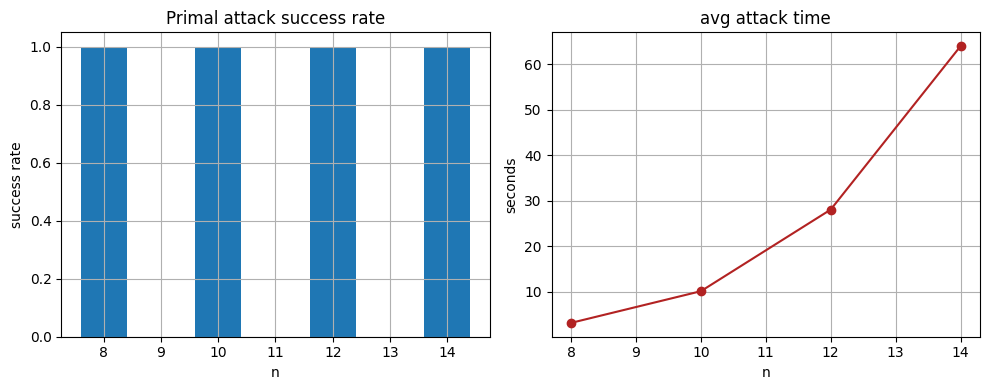

In [3]:
dims = [8, 10, 12, 14]
trials_per_dim = 2
success_rate = []
avg_time = []
for n in dims:
    successes = 0
    total_time = 0.0
    for trial in range(trials_per_dim):
        rng = np.random.default_rng(100 * n + trial)
        pk, _ = toy_keygen(n=n, q=max(31, 2 * n * n), sigma=0.8, rng=rng, m=2 * n, small_secret=True)
        t0 = time.time()
        result = primal_attack(pk, block_size=4, time_budget_s=90)
        total_time += time.time() - t0
        if result.status == 'success':
            successes += 1
    success_rate.append(successes / trials_per_dim)
    avg_time.append(total_time / trials_per_dim)
    print(f'n={n:2d}  success={successes}/{trials_per_dim}  avg time={avg_time[-1]:5.1f}s')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(dims, success_rate); axes[0].set_xlabel('n'); axes[0].set_ylabel('success rate'); axes[0].set_ylim(0, 1.05); axes[0].set_title('Primal attack success rate')
axes[1].plot(dims, avg_time, 'o-', color='firebrick'); axes[1].set_xlabel('n'); axes[1].set_ylabel('seconds'); axes[1].set_title('avg attack time')
for ax in axes: ax.grid(True)
plt.tight_layout(); plt.show()

## The pattern

- Small $n$ (≤ 15) falls to BKZ-4 reliably.
- Larger $n$ needs bigger $\beta$ — and since enumeration cost is ~ $2^{O(\beta)}$, our pure-Python version hits a wall.
- ML-KEM operates at effective lattice dimension ~$n \cdot k + m \cdot k \approx 512$–$1024$. To attack it, $\beta \approx 400+$ would be needed. That's where the $2^{140}$ cost estimate comes from — you can't do it.

→ Final chapter: `19_ml_kem_parameters_and_estimator.ipynb`